# Dataset Setup

##### Initial

In [5]:
import os
from pathlib import Path
from collections import Counter

import tensorflow as tf
import matplotlib.pyplot as plt

# Project / dataset configuration
DATASET_DIR = Path("../data/intel_dataset")

IMG_SIZE = (150, 150)
SEED = 42

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png"}

class_names = sorted([
    folder.name
    for folder in DATASET_DIR.iterdir()
    if folder.is_dir()
])

print("Dataset path:", DATASET_DIR)
print("Classes:", class_names)
print("Number of classes:", len(class_names))

expected_classes = {
    "buildings",
    "forest",
    "glacier",
    "mountain",
    "sea",
    "street"
}

assert set(class_names) == expected_classes, "Unexpected class structure!"

print("Dataset structure verified.")

file_paths = []
labels = []

for label, class_name in enumerate(class_names):
    class_dir = DATASET_DIR / class_name

    for file_path in class_dir.iterdir():
        if file_path.is_file() and file_path.suffix.lower() in VALID_EXTENSIONS:
            file_paths.append(str(file_path))
            labels.append(label)

print("Total images:", len(file_paths))

Dataset path: ..\data\intel_dataset
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of classes: 6
Dataset structure verified.
Total images: 16900


##### Class Distribution

Class distribution:

buildings: 2609
forest: 2745
glacier: 2874
mountain: 3027
sea: 2762
street: 2883


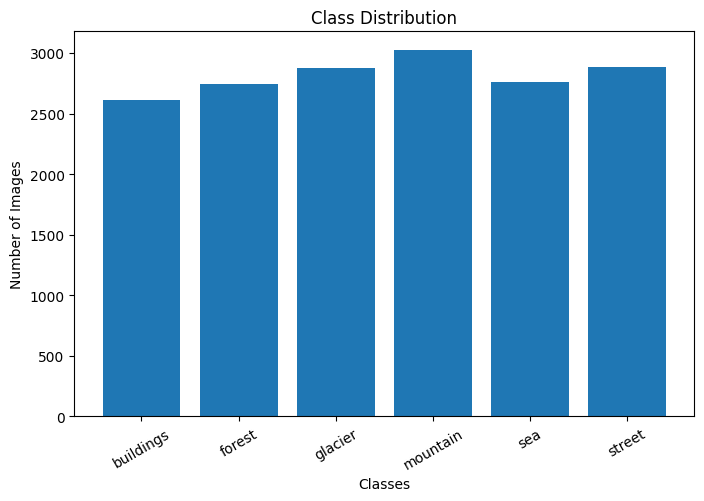

In [6]:
class_counts = Counter(labels)

print("Class distribution:\n")

for label, class_name in enumerate(class_names):
    print(f"{class_name}: {class_counts[label]}")

plt.figure(figsize=(8, 5))

counts = [class_counts[i] for i in range(len(class_names))]

plt.bar(class_names, counts)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.show()